#Atividades de vendas no brasil


In [290]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [291]:
df = pd.read_csv("../../data/vendas_brasil_1.csv")
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


#Entregavel 1 Numpy

In [292]:
print(df.columns)

Index(['data_venda', 'mes', 'cidade', 'canal_venda', 'categoria', 'produto',
       'vendedor', 'fidelidade_cliente', 'preco_unitario', 'custo_unitario',
       'margem_pct', 'quantidade', 'desconto_pct', 'receita_total', 'frete',
       'avaliacao_cliente', 'prazo_entrega_dias', 'devolucao',
       'entrega_no_prazo', 'alta_temporada', 'flag_outlier_preco'],
      dtype='str')


In [293]:
#A Criando arrays

preco = df["preco_unitario"].to_numpy()

custo = df["custo_unitario"].to_numpy()

quantidade = df["quantidade"].to_numpy()

desconto = df["desconto_pct"].to_numpy()

receita = df["receita_total"].to_numpy()

frete = df["frete"].to_numpy()

In [294]:
#B Calculos com operações vetorizadas

valor_bruto = preco * quantidade

valor_desconto = preco * (desconto/100)

custo_total = custo * quantidade

lucro_est = receita - custo_total - frete

In [295]:
#C Mascaras booleanas

vendas_acima = receita > np.mean(receita)

vendas_preju = lucro_est < 0

vendas_desc_alto = desconto > 25

print("Vendas com receita acima da media:",np.sum(vendas_acima))

print("Vendas com prejuizo:",np.sum(vendas_preju))

print("Vendas com desconto alto:",np.sum(vendas_desc_alto))

Vendas com receita acima da media: 9236
Vendas com prejuizo: 5857
Vendas com desconto alto: 2304


In [296]:
#D Agregações
receita_media = np.mean(receita)

maior_receita = np.max(receita)

menor_receita = np.min(receita)

lucro_medio = np.mean(lucro_est)

quant_vendas_preju =np.sum(vendas_preju)

print(f'A Receita media foi de {receita_media:.2f}')

print(f'A Maior receita foi {maior_receita}')

print(f'A Menor receita foi {menor_receita}')

print(f'O lucro medio foi de {lucro_medio:.2f}')

print(f'Quantidade de vendas com prejuizo:{quant_vendas_preju}')

A Receita media foi de 1891.69
A Maior receita foi 58430.28
A Menor receita foi 3.7
O lucro medio foi de nan
Quantidade de vendas com prejuizo:5857


In [297]:
#Ignorando o nan do lucro medio
lucro_medio = np.nanmean(lucro_est)
print(f'O lucro medio foi de {lucro_medio:.2f}')

O lucro medio foi de 482.38


#Com toda essa analise feita utilizando o Numpy, podemos concluir que no Brasil tivemos 9236 vendas com receita acima da media, 5857 vendas com prejuizo, considerando descontos acima de 20% como vendas com desconto alto tivemos 2304 vendas com alto desconto, nossa receita media total foi de 1891.69, sendo a maior receita de 58430.28 e a menor receita de 3.7, apos a correção do calculo de lucro medio, obtemos um lucro medio de 482.38 e uma quantidade de vendas com prejuizo de 5857

#Entregável 2 Pandas


In [298]:
#A Olhando o data set

df.head()
df.info()
df.describe()
df.shape
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

1. o dataset possui 37617 linhas e 21 colunas

2. Sim, no canal_venda, vendedor, margem_pct, frete, avaliacao_cliente e prazo_entrega_dias

3. As colunas mes, preco_unitario, custo_unitario, margem_pct, quantidade, desconto_pct, receita_total, frete, avaliacao_cliente e prazo_entrega_dias

4. As colunas data_venda, cidade, canal_venda, categoria, produto, vendedor, fidelidade_cliente, devolucao, entrega_no_prazo, alta_temporada, flag_outlier_preco

In [299]:
#B Limpeza e tratamento

df["data_venda"] = pd.to_datetime(df["data_venda"], format='mixed')
df["cidade"] = df["cidade"].str.strip().str.title()
cidade_padronizada = {
    "Rio De Janeiro": "Rio de Janeiro",
    "Rj": "Rio de Janeiro",
    "Rio": "Rio de Janeiro",
    "S. Paulo": "Sao Paulo",
    "Sp": "Sao Paulo",
    "São Paulo": "Sao Paulo",
    "Sao Paulo": "Sao Paulo",
    "Bh": "Belo Horizonte",
    "B. Horizonte": "Belo Horizonte",
    "Belo Horizonte": "Belo Horizonte",
    "Curitiba": "Curitiba",
    "Curtiba": "Curitiba",
    "Fortaleza": "Fortaleza",
    "Goiânia": "Goiania",
    "Manaus": "Manaus",
    "Porto Alegre": "Porto Alegre",
    "Recife": "Recife",
    "Slavador": "Salvador",
    "Salvador": "Salvador"
}
df["cidade"] = df["cidade"].replace(cidade_padronizada)

print(sorted(df["cidade"].unique()))


['Belo Horizonte', 'Curitiba', 'Fortaleza', 'Goiania', 'Manaus', 'Porto Alegre', 'Recife', 'Rio de Janeiro', 'Salvador', 'Sao Paulo']


In [300]:
## tratando dados faltantes
df["frete"].isna().sum()

df["frete"].describe()

df["frete"] = df["frete"].fillna(df["frete"].median()) #preenchi os valores com a mediana porque a mediana é menos sensivel a valores extremos do que a media

df["frete"].isna().sum()


np.int64(0)

In [301]:
#C Criação de novas colunas

df["ano_venda"] = df["data_venda"].dt.year

df["mes_venda"] = df["data_venda"].dt.month

df["lucro_total"] = ((df["receita_total"] - df["custo_unitario"]) * df["quantidade"]) - df["frete"]

df["receita_liquida"] = df["quantidade"] * df["preco_unitario"] - df["frete"]

df["faixa_receita"] = df["receita_liquida"].apply(
    lambda x: "Baixa" if x<1000 else "Media" if x <3000 else "Alta"
)

df[["ano_venda","mes_venda","lucro_total", "receita_liquida", "faixa_receita"]].head(8)


,ano_venda,mes_venda,lucro_total,receita_liquida,faixa_receita
0,2022,4,63708.62,7385.22,Alta
1,2023,3,3953.40,915.15,Baixa
2,2022,9,13951.42,1057.56,Media
3,2022,4,16522.41,1583.97,Media
4,2022,3,-22.50,111.03,Baixa
5,2023,12,7748.90,712.97,Baixa
6,2022,1,3830.64,707.58,Baixa
7,2023,9,933.40,189.34,Baixa


In [302]:
#D Filtros
#1 Quais vendas tiveram receita acima de determinado valor?
df[df["receita_total"]> 4000]



,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano_venda,mes_venda,lucro_total,receita_liquida,faixa_receita
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,5.0,False,True,False,False,2022,4,63708.62,7385.22,Alta
15,2022-04-10,4,Salvador,Marketplace,Eletrônicos,Smartphone,Ana Lima,Bronze,1213.88,843.05,...,12.0,False,False,False,True,2022,4,49673.19,8449.98,Alta
20,2022-12-10,12,Recife,Site Web,Eletrônicos,Smartphone,Inês Nunes,Prata,603.40,394.18,...,13.0,False,True,True,False,2022,12,151861.95,8378.75,Alta
21,2023-05-07,5,Sao Paulo,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,...,18.0,True,True,False,True,2023,5,49485.07,7132.75,Alta
23,2023-01-21,1,Manaus,Site Web,Esportes,Bicicleta,Carla Mendes,Bronze,257.83,207.71,...,13.0,False,True,True,False,2023,1,48981.01,3070.69,Alta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37566,2023-12-31,12,Salvador,Loja Física,Eletrônicos,Tablet,Inês Nunes,Prata,1383.40,878.95,...,NaN,False,False,True,True,2023,12,67997.54,9647.85,Alta
37574,2023-12-31,9,Rio de Janeiro,Site Web,Eletrônicos,Smartwatch,Elisa Costa,Ouro,739.62,507.93,...,12.0,False,True,False,False,2023,12,23648.43,4419.57,Alta
37578,2023-12-31,10,Manaus,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,1086.24,817.87,...,4.0,False,True,False,True,2023,12,99527.36,10839.26,Alta
37583,2023-12-31,2,Manaus,Loja Física,Eletrônicos,Smartwatch,Henrique Dias,Bronze,846.16,697.37,...,10.0,True,True,False,True,2023,12,84226.06,9293.73,Alta


Existem 4882 vendas com receita acima de 4000 reais

In [303]:
#2 Quais vendas tiveram devolução?
df[df["devolucao"] == True]


,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano_venda,mes_venda,lucro_total,receita_liquida,faixa_receita
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,19.0,True,False,False,False,2023,3,3953.40,915.15,Baixa
2,2022-09-28,9,Goiania,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,NaN,True,True,False,False,2022,9,13951.42,1057.56,Media
7,2023-09-07,9,Manaus,App Mobile,Alimentação,Mel Orgânico,Inês Nunes,Prata,35.72,21.62,...,18.0,True,False,False,False,2023,9,933.40,189.34,Baixa
18,2023-10-24,10,Manaus,Site Web,Vestuário,Camiseta,Carla Mendes,Prata,65.73,41.26,...,16.0,True,True,False,False,2023,10,837.39,206.31,Baixa
21,2023-05-07,5,Sao Paulo,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,...,18.0,True,True,False,True,2023,5,49485.07,7132.75,Alta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37522,2023-12-31,11,Salvador,Marketplace,Esportes,Bicicleta,Carla Mendes,Bronze,195.87,161.39,...,7.0,True,True,True,False,2023,12,37773.91,2539.36,Media
37525,2023-12-31,11,Curitiba,Loja Física,Esportes,Luva de Box,Ana Lima,Prata,248.42,183.21,...,13.0,True,True,True,False,2023,12,38062.87,2972.47,Media
37533,2023-12-31,5,Belo Horizonte,App Mobile,Alimentação,Granola,Henrique Dias,Prata,48.60,36.51,...,14.0,True,True,False,False,2023,12,702.20,229.85,Baixa
37583,2023-12-31,2,Manaus,Loja Física,Eletrônicos,Smartwatch,Henrique Dias,Bronze,846.16,697.37,...,10.0,True,True,False,True,2023,12,84226.06,9293.73,Alta


3532 vendas tiveram que ser devolvidas

In [304]:
#3 Quais vendas pertencem a uma categoria específica?
df[df["categoria"] == 'Eletrônicos']

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano_venda,mes_venda,lucro_total,receita_liquida,faixa_receita
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,5.0,False,True,False,False,2022,4,63708.62,7385.22,Alta
15,2022-04-10,4,Salvador,Marketplace,Eletrônicos,Smartphone,Ana Lima,Bronze,1213.88,843.05,...,12.0,False,False,False,True,2022,4,49673.19,8449.98,Alta
17,2022-05-11,5,Belo Horizonte,App Mobile,Eletrônicos,Smartwatch,Elisa Costa,Prata,732.37,536.37,...,4.0,False,True,False,False,2022,5,16620.60,4345.50,Alta
20,2022-12-10,12,Recife,Site Web,Eletrônicos,Smartphone,Inês Nunes,Prata,603.40,394.18,...,13.0,False,True,True,False,2022,12,151861.95,8378.75,Alta
21,2023-05-07,5,Sao Paulo,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,...,18.0,True,True,False,True,2023,5,49485.07,7132.75,Alta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37589,2023-12-31,4,Rio de Janeiro,App Mobile,Eletrônicos,Fone Bluetooth,Fábio Ramos,Bronze,899.09,734.88,...,8.0,True,False,False,True,2023,12,13353.12,4475.37,Alta
37593,2023-12-31,2,Manaus,Site Web,Eletrônicos,Tablet,Gabi Alves,Ouro,565.19,385.88,...,17.0,False,False,False,False,2023,12,25923.83,4444.39,Alta
37600,2023-12-31,12,Fortaleza,App Mobile,Eletrônicos,Tablet,Henrique Dias,Ouro,212.67,167.18,...,6.0,False,True,True,False,2023,12,162.58,205.58,Baixa
37603,2023-12-31,9,Rio de Janeiro,App Mobile,Eletrônicos,Tablet,Inês Nunes,Prata,963.50,608.11,...,3.0,False,True,False,True,2023,12,19713.86,4799.31,Alta


Foram feitas 7515 vendas de eletronicos

In [305]:
#E Agrupamentos com groupby

df_maior_receita = df.groupby('categoria')['receita_total'].sum().sort_values(ascending=False)

print(df_maior_receita)

categoria
Eletrônicos    45017479.88
Esportes       11567480.75
Vestuário       6780473.93
Livros          4462597.93
Alimentação     3331601.51
Name: receita_total, dtype: float64


A categoria Eletrônicos tiveram a maior receita total

In [306]:
#2 Qual canal de venda teve maior quantidade de vendas?
df_canal_mais_vendido = df.groupby('canal_venda')['quantidade'].sum().sort_values(ascending=False)

print(df_canal_mais_vendido)

canal_venda
Site Web       84503
App Mobile     83188
Loja Física    56318
Marketplace    41707
Televendas     13726
app mobile       240
SiteWeb          231
APP Mobile       221
Site web         203
App mobile       190
loja física      180
site web         154
Loja Fisica      109
Loja fisica       98
Name: quantidade, dtype: int64


O canal de vendas Site Web foi o que masi realizou vendas

In [307]:
#3 Qual cidade teve maior receita?
df_cidade_maior_receita = df.groupby('cidade')["receita_total"].sum().sort_values(ascending=False)

print(df_cidade_maior_receita)

cidade
Recife            7662241.79
Manaus            7459161.23
Fortaleza         7242081.82
Goiania           7178113.69
Porto Alegre      7048428.17
Curitiba          6993175.07
Salvador          6918656.01
Belo Horizonte    6914747.61
Rio de Janeiro    6880176.34
Sao Paulo         6862852.27
Name: receita_total, dtype: float64


A cidade de Recife foi a cidade com maior receita

In [308]:
#4  Qual categoria teve maior lucro?

df_catg_maior_lucro = df.groupby('categoria')['lucro_total'].sum().sort_values(ascending=False)

print(df_catg_maior_lucro)

categoria
Eletrônicos    4.061464e+08
Esportes       1.150616e+08
Vestuário      6.214312e+07
Livros         4.256637e+07
Alimentação    2.937316e+07
Name: lucro_total, dtype: float64


A categoria de eletronicos teve o maior lucro

In [309]:
#F Merge

regioes = pd.DataFrame({
    "cidade":[
    "Sao Paulo",
    "Belo Horizonte",
    "Fortaleza",
    "Recife",
    "Curitiba",
    "Rio de Janeiro",
    "Porto Alegre",
    "Manaus",
    "Goiania",
    "Salvador"
    ],
    "regiao":[
    "Sudeste",
    "Sudeste",
    "Nordeste",
    "Nordeste",
    "Sul",
    "Sudeste",
    "Sul",
    "Norte",
    "Centro Oeste",
    "Nordeste"
    ]
}
)
df = df.merge(regioes, on="cidade", how="left")

df_receita_tot_regiao = df.groupby('regiao')['receita_total'].sum().sort_values(ascending=False)

print(df_receita_tot_regiao)




regiao
Nordeste        21822979.62
Sudeste         20657776.22
Sul             14041603.24
Norte            7459161.23
Centro Oeste     7178113.69
Name: receita_total, dtype: float64


Notamos que a regiao que possui a maior receita é a regiao Nordeste

#Entregavel 3 Seaborn

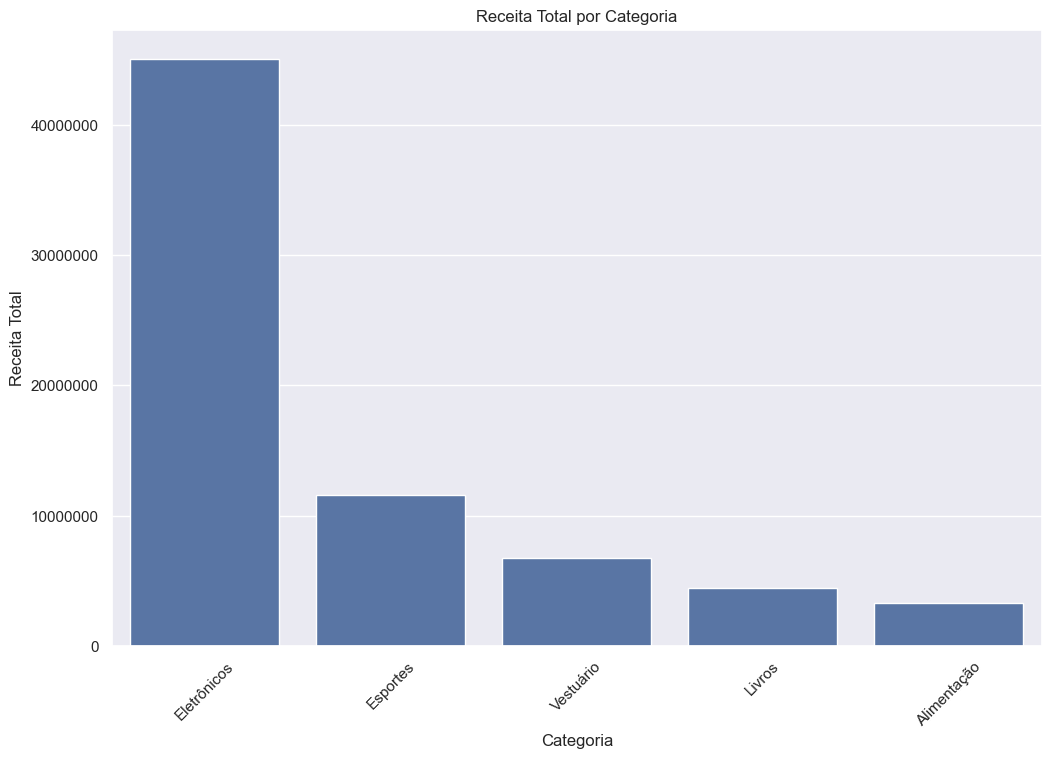

In [ ]:
#A grafico de barras
plt.figure(figsize=(12,8))
sns.barplot(df_maior_receita.reset_index(),
 x ="categoria",
 y ="receita_total")

plt.title('Receita Total por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Receita Total')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')

plt.show()

O grafico mostra como a receita total da Categoria Eletrônicos foi disparada a maior entre todas as categorias 

    mes_venda  receita_total
0          12     7914340.14
1           1     7581647.81
2          11     7044286.58
3           9     5704690.41
4           7     5560976.01
5           4     5551580.55
6          10     5526055.05
7           8     5503323.54
8           3     5446515.44
9           6     5354590.32
10          5     5223020.54
11          2     4748607.61


<function matplotlib.pyplot.show(close=None, block=None)>

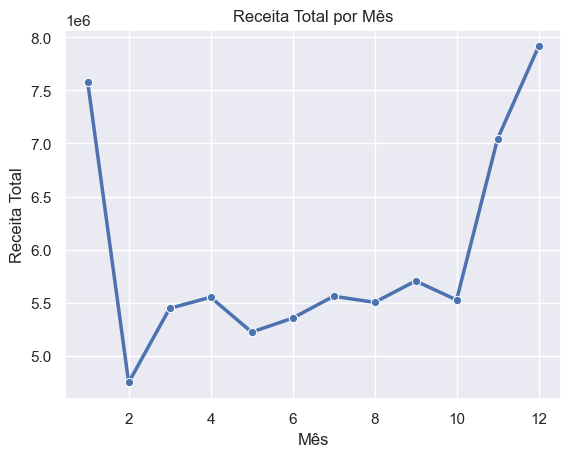

In [ ]:
#B grafico de linhas
df_receita_mes = df.groupby('mes_venda')['receita_total'].sum().sort_values(ascending=False).reset_index()
print(df_receita_mes)

plt.Figure(figsize=(10,5))

sns.lineplot(df_receita_mes,
    x ="mes_venda",
    y ="receita_total",
    marker = "o",
    linewidth=2.5)

plt.title('Receita Total por Mês')
plt.xlabel('Mês')
plt.ylabel('Receita Total')
plt.grid(True)
plt.show


O grafico mostra que nos meses finais do ano a receita aumenta significativamente e um declinio alto no mes 2


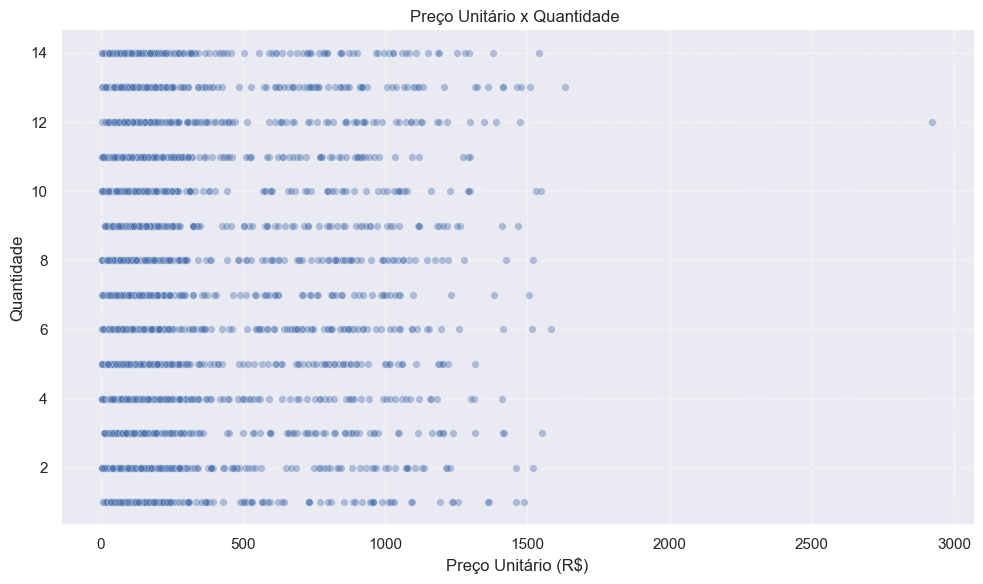

In [ ]:
#C grafico de dispersao
figura = df.sample(frac=0.1, random_state=30)

plt.figure(figsize=(10,6))

sns.scatterplot(
    figura,
    x='preco_unitario',
    y='quantidade',
    alpha=0.4,
    s=30
)

plt.title('Preço Unitário x Quantidade ')
plt.xlabel('Preço Unitário')
plt.ylabel('Quantidade')

sns.despine()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

O grafico indica que a maior parte das vendas está concentrada em pordutos com preço abaixo de 1000 e também é possivel observar que não há uma relação linear entre preço unitário e quantidade, já que os pontos estao bastante dispersos.

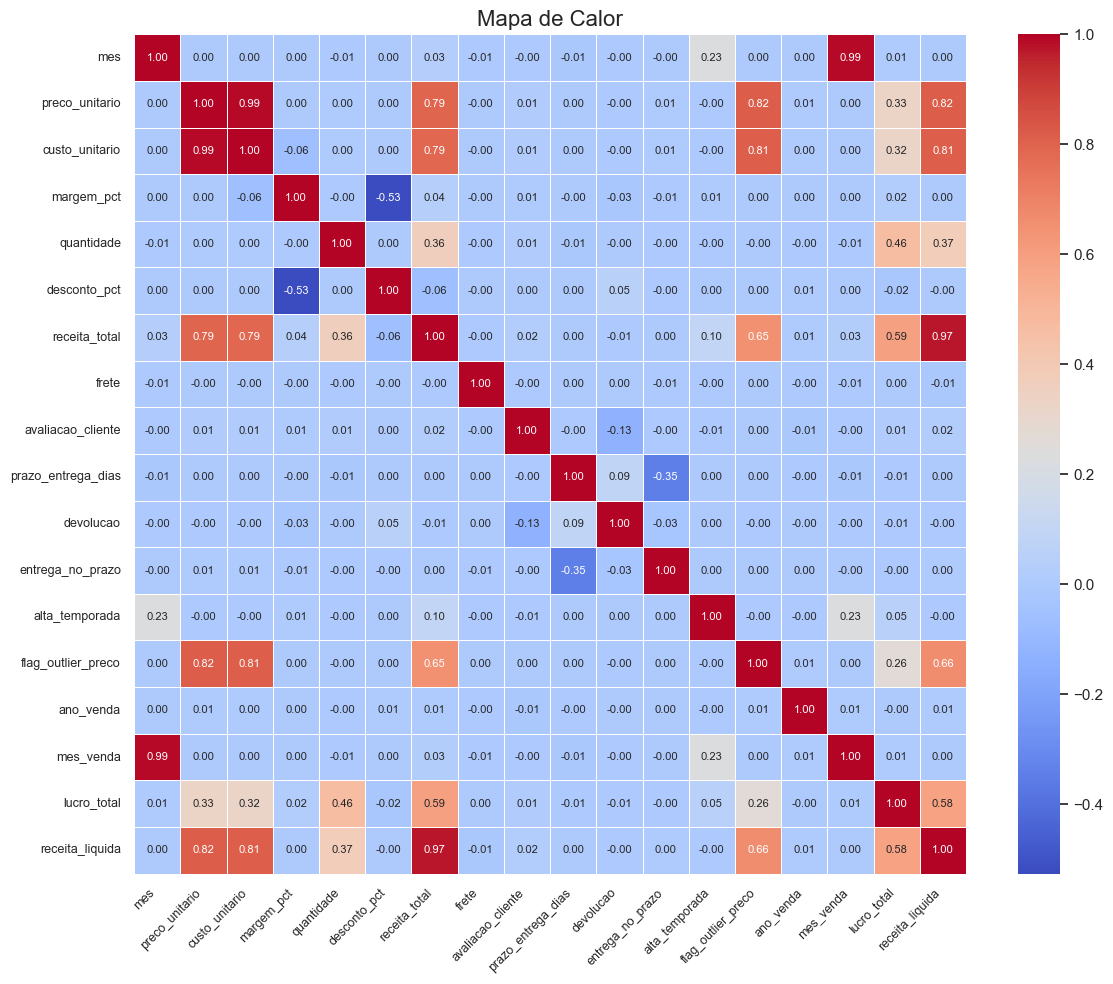

In [ ]:
#D Mapa de Calor
map_calor = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(map_calor,
    annot=True,
    cmap='coolwarm',
    
    fmt='.2f',
    linewidths=0.5,
    annot_kws={"size":8}
)
plt.title("Mapa de Calor",fontsize=16)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

O mapa de calor mostra que a maior parte das variaveis possuem baixa correlação, tendo em alguns casos correlações positivas altas, como entre preço unitario e custo unitario, receita total e receita liquida. Entretanto, margem_pct e desconto_pct possui uma correlação negativa de (-0,53) o que mostra que um aumento nos descontos tende a reduzir a margem de lucro.